# РК 1. EDA-анализ данных об SQL-инъекциях

Цель анализа — исследовать структуру преподавательского датасета, распределения категорий и типов атак, используемые инструменты, MITRE-техники, теги, источники и текстовые поля, а также выявить основные закономерности.

Перед запуском выполните `client.py`, чтобы получить `sql_injections_merged.csv`.

In [1]:
from collections import Counter
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

CSV_PATH = Path("sql_injections_merged.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(
        "Файл sql_injections_merged.csv не найден. Сначала выполните: python client.py"
    )

df = pd.read_csv(CSV_PATH)
original_columns = df.columns.tolist()

print(f"Загружено строк: {len(df):,}")
print(f"Столбцов: {len(df.columns)}")
display(df.head())

Загружено строк: 14,133
Столбцов: 15


,id,Title,Category,Attack Type,Scenario Description,Attack Steps,Tools Used,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),"A login form fails to validate or sanitize input, allowing attackers to log in as admin without knowing the password.","1. Reconnaissance: Find a login form on the website (e.g., username and password fields). 2. Test for Injection: Ent...","Browser, Burp Suite, SQLMap","Web Login Portals (e.g., banking, admin dashboards, e-commerce)",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-Facing App)","Full account takeover, data theft, privilege escalation","Web server logs, anomaly detection (e.g., logins without passwords), WAF alerts","Use prepared statements, Sanitize inputs, Limit login attempts, Use CAPTCHA, Enable MFA","SQLi, Authentication Bypass, Web Security, OWASP Top 10","OWASP, MITRE ATT&CK, DVWA"
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,"This attack occurs when a hacker uses the SQL ""UNION"" operator to combine results from a malicious query with a legi...","1. Identify User Input Points: Attacker finds a search bar, login form, or URL that interacts with the database. 2. ...","SQLMap, Burp Suite, Havij, Browser Developer Tools","Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQL queries to be altered,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeover, Unauthorized database access",Web Application Firewalls (WAF)Log AnalysisInput Sanitization LogsSQL Error Monitoring,Use parameterized queries (Prepared Statements)Sanitize all user inputsDisable detailed SQL error messagesApply leas...,#SQLInjection #WebSecurity #UnionAttack #OWASPTop10 #InjectionFlaws,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web Security Academy"
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentionally triggers database errors to extract information. These errors ofte...,"1. Identify Input Points:Attacker finds a field like login, search, or URL parameter that interacts with a database....","SQLMap, Burp Suite, Manual Browser Testing, Havij","Web Applications, Login Forms, URL Parameters, Admin Panels",Error message exposure due to lack of input validation and improper database handling,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exposure, Entry point for further attacks, Sensitive data leakage",Review and monitor error logsEnable generic error pagesMonitor for unusual user inputsUse WAF to detect SQL errors,Turn off detailed error messages in productionUse parameterized queriesInput validation and sanitizationRegular vuln...,#SQLInjection #ErrorLeakage #WebAppSecurity #OWASPTop10 #DatabaseSecurity,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web Security Academy"
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesn’t see error messages or data output directly, but can still extract data ...","1. Find a User Input Point:Attacker finds a place where user input is passed to the database, such as a login form, ...","SQLMap, Burp Suite, sqlninja, Manual Browser Testing, Python Scripts","Web Applications, Login Pages, Search Fields, Query Parameters","No error messages, but user input is still passed to the database and not properly sanitized",T1190 – Exploit Public-Facing Application,Slow and stealthy data theftFull database compromise over timeCredential and sensitive info leakage,Monitor for slow and repetitive requestsAnalyze behavioral anomalies in logsUse IDS/IPS and WAF to detect patterns,Use parameterized queries (prepared statements)Sanitize and validate all inputHide system errors from usersRate limi...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWASPTop10 #DatabaseHacking,"OWASP, MITRE ATT&CK, Acuneti

In [2]:
def split_values(series, pattern=r"[,;#]", lower=False):
    values = []
    for value in series.dropna().astype(str):
        for part in re.split(pattern, value):
            token = part.strip()
            if lower:
                token = token.lower()
            if token:
                values.append(token)
    return values


def plot_counter(counter, top_n, title):
    top = pd.Series(dict(counter.most_common(top_n)), dtype="int64")
    if top.empty:
        print("Нет данных для построения графика")
        return top

    plt.figure(figsize=(10, max(5, top_n * 0.32)))
    top.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Количество")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
    return top


def pct(part, whole):
    return 0.0 if whole == 0 else 100 * part / whole


def fmt_int(value):
    return f"{int(value):,}".replace(",", " ")

## 1. Общая информация: размер, типы, пропуски и дубликаты

Размер DataFrame: (14133, 15)


,dtype
id,int64
Title,str
Category,str
Attack Type,str
Scenario Description,str
Attack Steps,str
Tools Used,str
Target Type,str
Vulnerability,str
MITRE Technique,str


,missing_count,missing_percent
Source,160,1.13
MITRE Technique,24,0.17
Vulnerability,18,0.13
Tools Used,14,0.10
Target Type,4,0.03
Detection Method,4,0.03
Impact,3,0.02
Solution,3,0.02
Tags,3,0.02
id,0,0.00


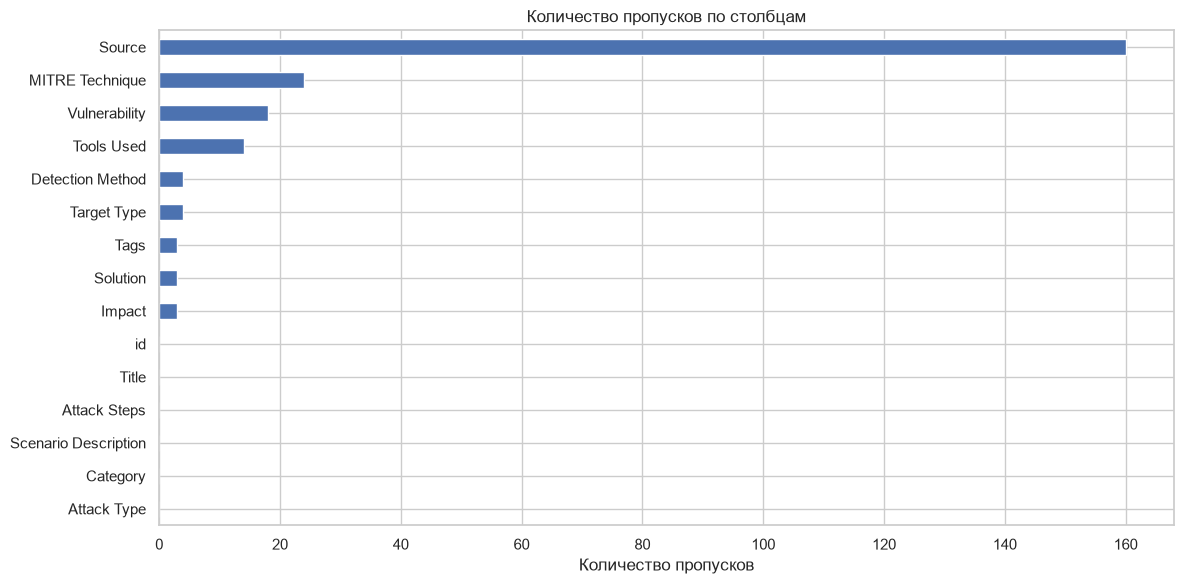

Вывод: число строк — 14 133, число исходных столбцов — 15. Всего пропущено 233 значений (0.11% всех ячеек); максимум пропусков в поле 'Source' — 160 (1.13%).
Полных дубликатов строк: 0, повторяющихся id: 0. Следовательно, объём пропусков невелик и структура данных пригодна для дальнейшего EDA без удаления значительной части наблюдений.


In [3]:
print("Размер DataFrame:", df.shape)
display(df.dtypes.to_frame("dtype"))

missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
}).sort_values(["missing_count", "missing_percent"], ascending=False)
display(missing)

plt.figure(figsize=(12, 6))
missing["missing_count"].sort_values().plot(kind="barh")
plt.title("Количество пропусков по столбцам")
plt.xlabel("Количество пропусков")
plt.tight_layout()
plt.show()

duplicates = int(df.duplicated().sum())
duplicate_ids = int(df["id"].duplicated().sum())
total_missing = int(df.isna().sum().sum())
total_cells = int(df.shape[0] * df.shape[1])
max_col = missing.index[0]
max_count = int(missing.iloc[0]["missing_count"])
max_percent = float(missing.iloc[0]["missing_percent"])

print(
    f"Вывод: число строк — {fmt_int(len(df))}, число исходных столбцов — {len(original_columns)}. "
    f"Всего пропущено {total_missing} значений ({pct(total_missing, total_cells):.2f}% всех ячеек); "
    f"максимум пропусков в поле '{max_col}' — {max_count} ({max_percent:.2f}%)."
)
print(
    f"Полных дубликатов строк: {duplicates}, повторяющихся id: {duplicate_ids}. "
    "Следовательно, объём пропусков невелик и структура данных пригодна для дальнейшего EDA без удаления значительной части наблюдений."
)

## 2. Анализ `Category`

,count,share_%
Category,,
Insider Threat,569,4.03
Physical / Hardware Attacks,548,3.88
Quantum Cryptography & Post-Quantum Threats,542,3.83
Wireless Attacks (Advanced),535,3.79
Malware & Threat,528,3.74
Satellite & Space Infrastructure Security,515,3.64
DFIR,510,3.61
Blockchain / Web3,503,3.56
Red Team,503,3.56


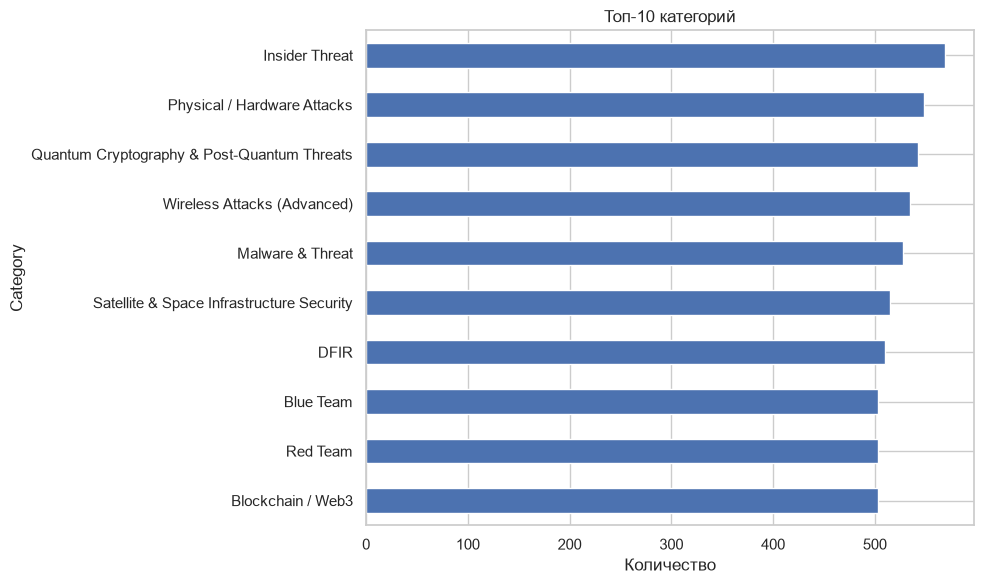

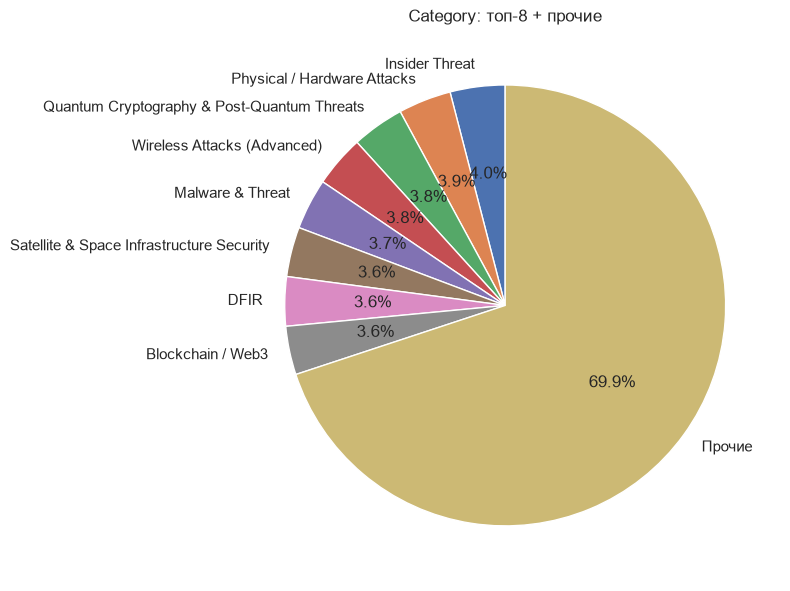

Вывод: число уникальных категорий — 64. Наиболее частая — 'Insider Threat' (569 записей; 4.03%).
Топ-10 категорий охватывают 37.19% наблюдений, при этом ни одна категория не занимает подавляющую долю. Распределение можно считать достаточно равномерным среди ведущих категорий, с выраженным длинным хвостом менее частых значений.


In [4]:
category_counts = df["Category"].fillna("<NULL>").value_counts()
category_share = (df["Category"].fillna("<NULL>").value_counts(normalize=True) * 100).round(2)

category_table = pd.DataFrame({
    "count": category_counts,
    "share_%": category_share,
})
display(category_table.head(10))

plt.figure(figsize=(10, 6))
category_counts.head(10).sort_values().plot(kind="barh")
plt.title("Топ-10 категорий")
plt.xlabel("Количество")
plt.tight_layout()
plt.show()

pie = category_counts.head(8).copy()
other = int(category_counts.iloc[8:].sum())
if other:
    pie.loc["Прочие"] = other

plt.figure(figsize=(8, 8))
plt.pie(pie.values, labels=pie.index, autopct="%1.1f%%", startangle=90)
plt.title("Category: топ-8 + прочие")
plt.tight_layout()
plt.show()

top10_share = pct(category_counts.head(10).sum(), len(df))
print(
    f"Вывод: число уникальных категорий — {df['Category'].nunique(dropna=True)}. "
    f"Наиболее частая — '{category_counts.index[0]}' ({category_counts.iloc[0]} записей; {category_share.iloc[0]:.2f}%)."
)
print(
    f"Топ-10 категорий охватывают {top10_share:.2f}% наблюдений, при этом ни одна категория не занимает подавляющую долю. "
    "Распределение можно считать достаточно равномерным среди ведущих категорий, с выраженным длинным хвостом менее частых значений."
)

## 3. Анализ `Attack Type`

,count
Attack Type,
Hardware Interface Exploitation,161
Wireless Attacks (Advanced),95
Dependency Confusion,91
Fuzzer Configuration,75
Malicious Libraries,74
Malicious Library,71
Privilege Escalation,61
Misuse of Legitimate Tools,55
Removable Media Attack,55


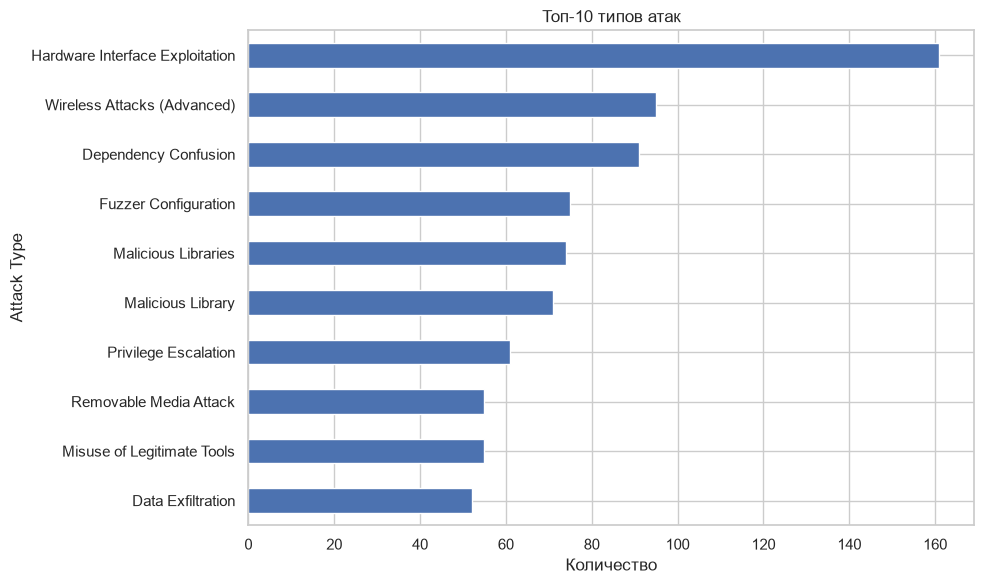

Вывод: наиболее частый тип — 'Hardware Interface Exploitation', частота — 161. Всего обнаружено 8 834 уникальных типов атак, что эквивалентно 62.51% от числа строк.
7 974 типов (90.26% всех уникальных Attack Type) встречаются только один раз, а топ-10 типов покрывают лишь 5.59% датасета. Это указывает на очень высокую уникальность и разнообразие поля `Attack Type`.


In [5]:
attack_counts = df["Attack Type"].fillna("<NULL>").value_counts()
display(attack_counts.head(10).to_frame("count"))

plt.figure(figsize=(10, 6))
attack_counts.head(10).sort_values().plot(kind="barh")
plt.title("Топ-10 типов атак")
plt.xlabel("Количество")
plt.tight_layout()
plt.show()

unique_attack_types = df["Attack Type"].nunique(dropna=True)
unique_ratio = pct(unique_attack_types, len(df))
singleton_types = int((df["Attack Type"].value_counts() == 1).sum())
singleton_share = pct(singleton_types, unique_attack_types)
top10_attack_share = pct(attack_counts.head(10).sum(), len(df))

print(
    f"Вывод: наиболее частый тип — '{attack_counts.index[0]}', частота — {attack_counts.iloc[0]}. "
    f"Всего обнаружено {fmt_int(unique_attack_types)} уникальных типов атак, что эквивалентно {unique_ratio:.2f}% от числа строк."
)
print(
    f"{fmt_int(singleton_types)} типов ({singleton_share:.2f}% всех уникальных Attack Type) встречаются только один раз, "
    f"а топ-10 типов покрывают лишь {top10_attack_share:.2f}% датасета. Это указывает на очень высокую уникальность и разнообразие поля `Attack Type`."
)

## 4. Анализ `Tools Used`

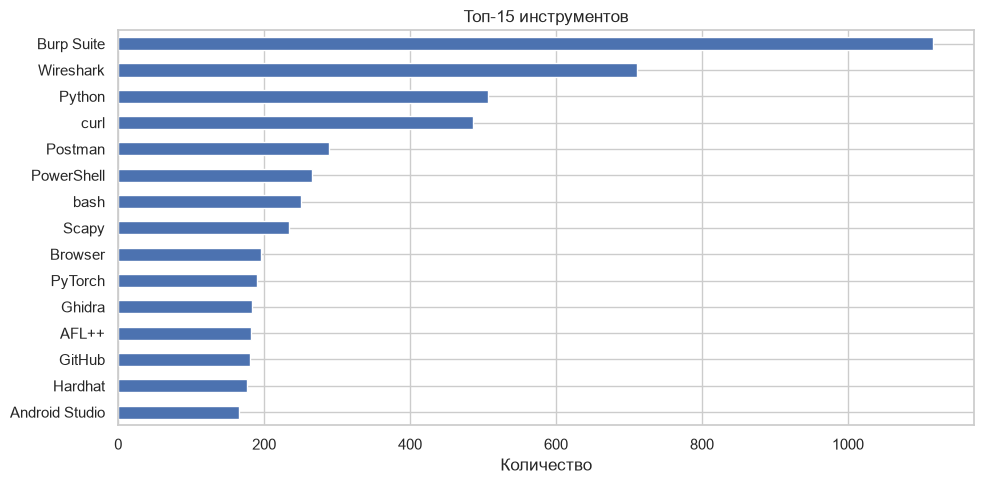

,count
Burp Suite,1117
Wireshark,711
Python,507
curl,486
Postman,289
PowerShell,265
bash,251
Scapy,234
Browser,196
PyTorch,190


Вывод: наиболее часто встречаются Burp Suite (1117), Wireshark (711), Python (507), curl (486), Postman (289).
Набор лидирующих инструментов сочетает средства веб-тестирования, анализа сетевого трафика и скриптовой/CLI-автоматизации. Это показывает, что типичный технический стек в датасете не ограничивается одним классом инструментов.


In [6]:
tools = split_values(df["Tools Used"], pattern=r"[,;#]")
tools_counter = Counter(tools)
top_tools = plot_counter(tools_counter, 15, "Топ-15 инструментов")
display(top_tools.sort_values(ascending=False).to_frame("count"))

top5_tools = tools_counter.most_common(5)
print(
    "Вывод: наиболее часто встречаются "
    + ", ".join(f"{name} ({count})" for name, count in top5_tools)
    + "."
)
print(
    "Набор лидирующих инструментов сочетает средства веб-тестирования, анализа сетевого трафика и скриптовой/CLI-автоматизации. "
    "Это показывает, что типичный технический стек в датасете не ограничивается одним классом инструментов."
)

## 5. Анализ `MITRE Technique`

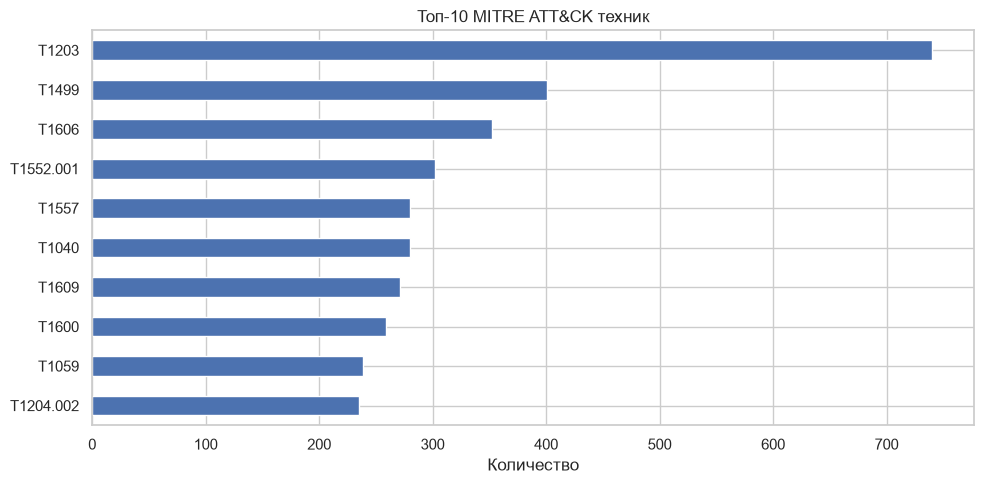

,count
T1203,740
T1499,401
T1606,352
T1552.001,302
T1040,280
T1557,280
T1609,271
T1600,259
T1059,239
T1204.002,235


Вывод: наиболее частые MITRE-техники — T1203 (740), T1499 (401), T1606 (352), T1552.001 (302), T1040 (280).
Всего из поля `MITRE Technique` извлечено 15 214 идентификаторов, соответствующих заданному шаблону MITRE-кода. Разнообразие техник согласуется с высокой вариативностью типов атак; их непосредственная связь с `Attack Type` отдельно рассматривается в пункте 9.


In [7]:
mitre_pattern = r"T\d{4}(?:\.\d{3})?"
mitre_all = []

for value in df["MITRE Technique"].dropna().astype(str):
    mitre_all.extend(re.findall(mitre_pattern, value))

mitre_counter = Counter(mitre_all)
top_mitre = plot_counter(mitre_counter, 10, "Топ-10 MITRE ATT&CK техник")
display(top_mitre.sort_values(ascending=False).to_frame("count"))

top5_mitre = mitre_counter.most_common(5)
print(
    "Вывод: наиболее частые MITRE-техники — "
    + ", ".join(f"{name} ({count})" for name, count in top5_mitre)
    + "."
)
print(
    f"Всего из поля `MITRE Technique` извлечено {fmt_int(len(mitre_all))} идентификаторов, соответствующих заданному шаблону MITRE-кода. "
    "Разнообразие техник согласуется с высокой вариативностью типов атак; их непосредственная связь с `Attack Type` отдельно рассматривается в пункте 9."
)

## 6. Анализ `Tags`

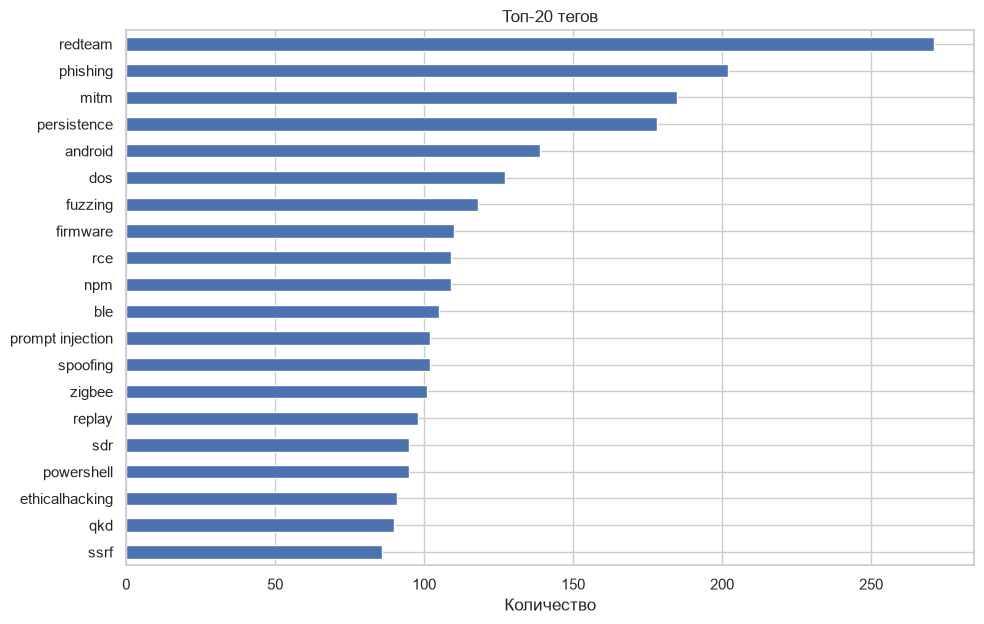

,count
redteam,271
phishing,202
mitm,185
persistence,178
android,139
dos,127
fuzzing,118
firmware,110
rce,109
npm,109


Вывод: наиболее частые теги — redteam (271), phishing (202), mitm (185), persistence (178), android (139).
Лидирующие теги `redteam`, `phishing`, `mitm`, `persistence` и `android` показывают, что в наборе заметно представлены как наступательные сценарии, так и сетевые, социальные и платформенные аспекты атак.


In [8]:
tags = split_values(df["Tags"], pattern=r"[,;#]", lower=True)
tags_counter = Counter(tags)
top_tags = plot_counter(tags_counter, 20, "Топ-20 тегов")
display(top_tags.sort_values(ascending=False).to_frame("count"))

top5_tags = tags_counter.most_common(5)
print(
    "Вывод: наиболее частые теги — "
    + ", ".join(f"{name} ({count})" for name, count in top5_tags)
    + "."
)
print(
    "Лидирующие теги `redteam`, `phishing`, `mitm`, `persistence` и `android` показывают, "
    "что в наборе заметно представлены как наступательные сценарии, так и сетевые, социальные и платформенные аспекты атак."
)

## 7. Анализ `Source`

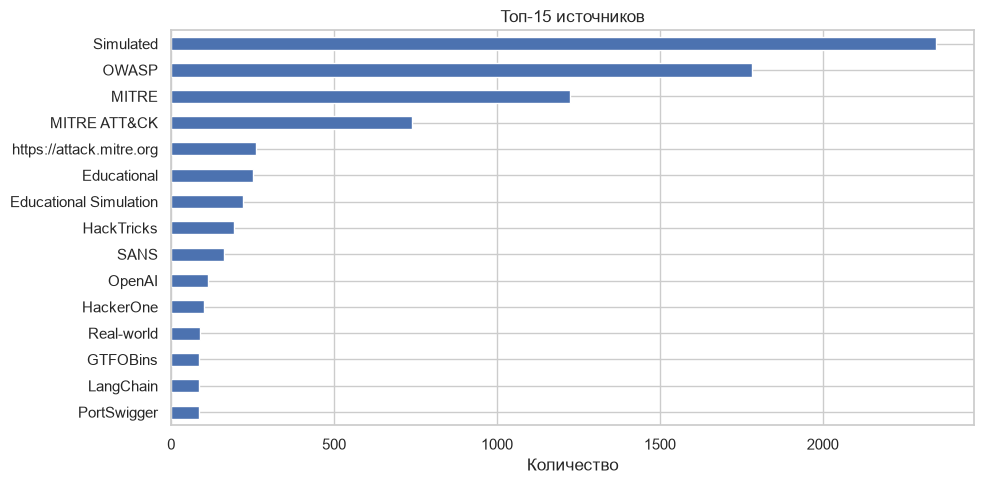

,count
Simulated,2347
OWASP,1783
MITRE,1225
MITRE ATT&CK,738
https://attack.mitre.org,259
Educational,251
Educational Simulation,219
HackTricks,194
SANS,163
OpenAI,114


Вывод: наиболее часто встречаются источники/обозначения Simulated (2347), OWASP (1783), MITRE (1225), MITRE ATT&CK (738), https://attack.mitre.org (259).
По частоте лидирует `Simulated`. Среди явно именованных отраслевых источников особенно заметны OWASP, MITRE и MITRE ATT&CK, которые формируют существенную часть ссылочной базы датасета.


In [9]:
sources = split_values(df["Source"], pattern=r"[,;]")
sources_counter = Counter(sources)
top_sources = plot_counter(sources_counter, 15, "Топ-15 источников")
display(top_sources.sort_values(ascending=False).to_frame("count"))

top5_sources = sources_counter.most_common(5)
print(
    "Вывод: наиболее часто встречаются источники/обозначения "
    + ", ".join(f"{name} ({count})" for name, count in top5_sources)
    + "."
)
print(
    "По частоте лидирует `Simulated`. Среди явно именованных отраслевых источников особенно заметны OWASP, MITRE и MITRE ATT&CK, "
    "которые формируют существенную часть ссылочной базы датасета."
)

## 8. `Category × Attack Type`

Attack Type,Data Exfiltration,Hardware Interface Exploitation,Misuse of Legitimate Tools,Privilege Escalation,Removable Media Attack,Wireless Attacks (Advanced)
Category,,,,,,
Blue Team,8,0,0,3,0,0
DFIR,0,0,0,1,0,0
Insider Threat,37,0,55,45,0,0
Physical / Hardware Attacks,0,161,0,0,55,0
Quantum Cryptography & Post-Quantum Threats,0,0,0,0,0,95
Red Team,0,0,0,2,0,0


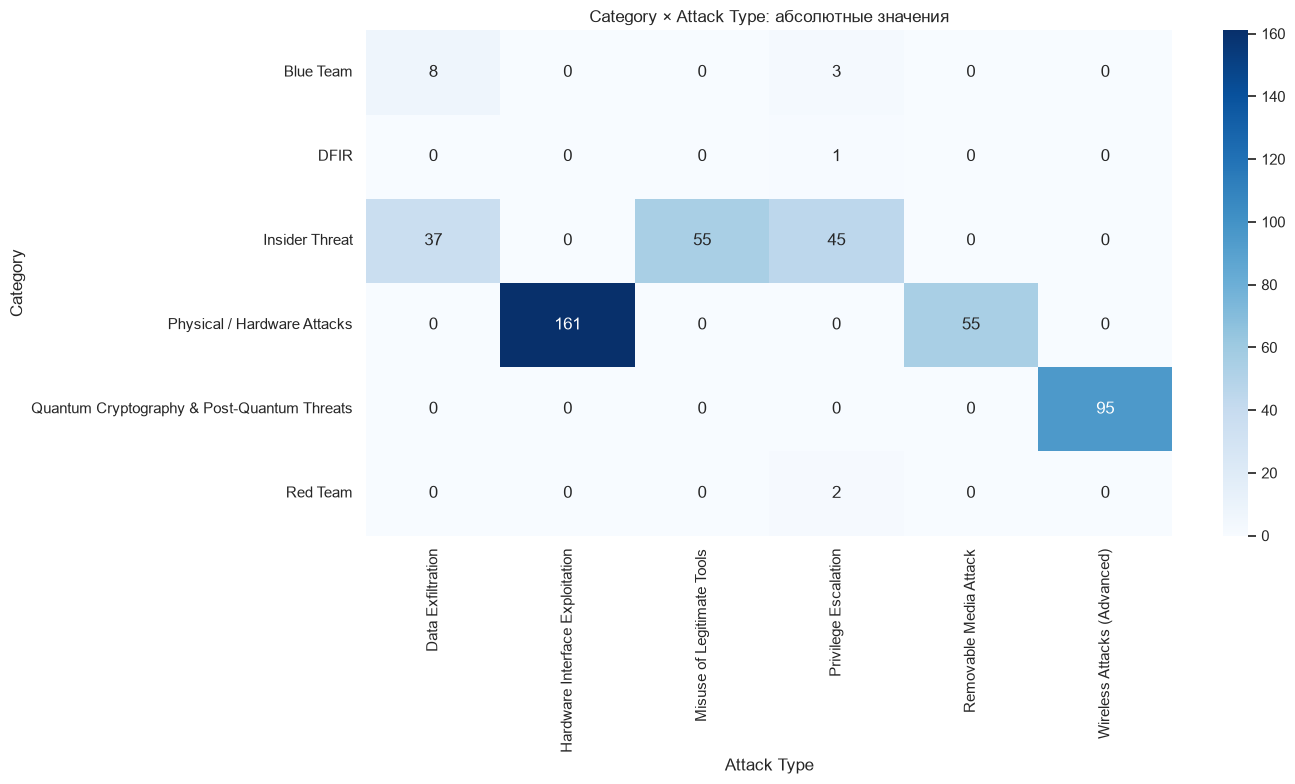

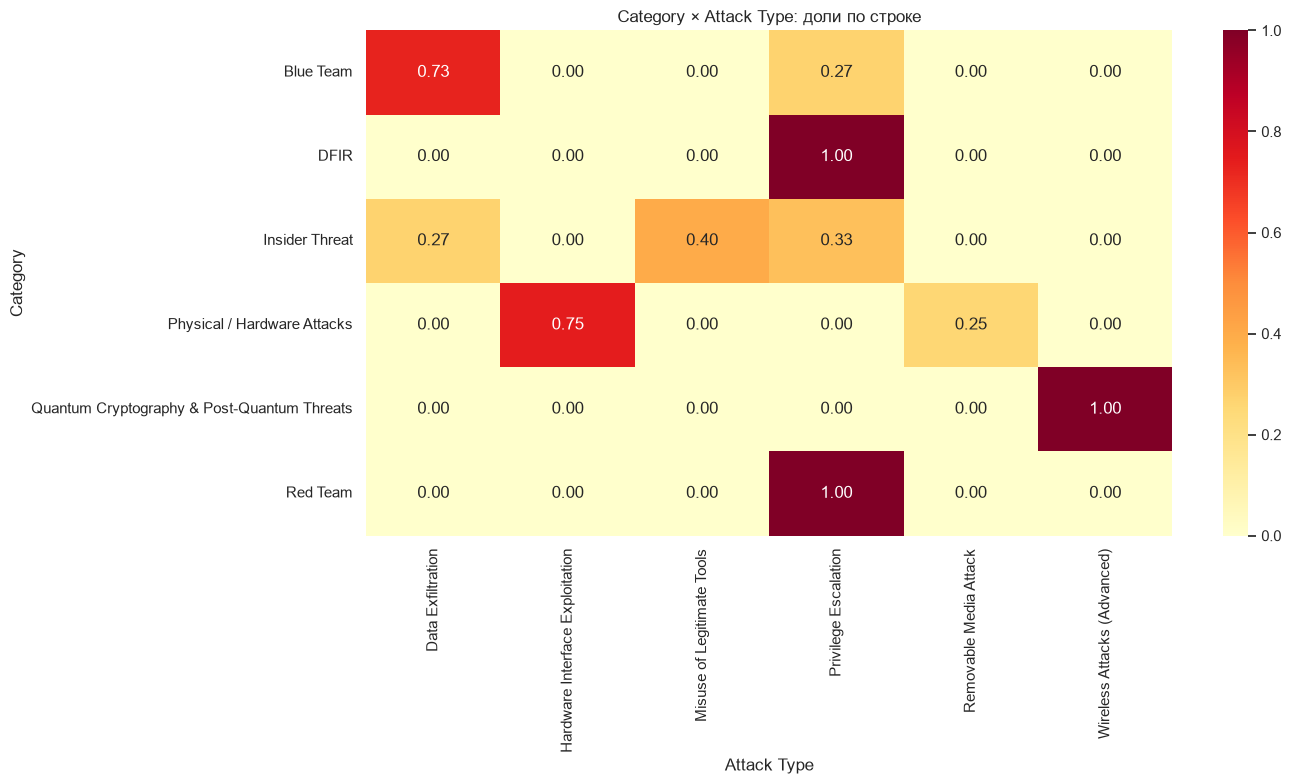

Вывод: наиболее выраженная пара — 'Physical / Hardware Attacks' → 'Hardware Interface Exploitation', частота — 161. В строке этой категории внутри матрицы топ-10 данный тип составляет 74.54%.
Следовательно, между отдельными категориями и типами атак присутствуют выраженные частотные связи; абсолютная и нормированная heatmap позволяют увидеть их с разных сторон.


In [10]:
top_categories = df["Category"].value_counts().head(10).index
top_attacks = df["Attack Type"].value_counts().head(10).index

subset = df[
    df["Category"].isin(top_categories)
    & df["Attack Type"].isin(top_attacks)
]

ct_cat_attack = pd.crosstab(subset["Category"], subset["Attack Type"])
display(ct_cat_attack)

plt.figure(figsize=(14, 8))
sns.heatmap(ct_cat_attack, annot=True, fmt="d", cmap="Blues")
plt.title("Category × Attack Type: абсолютные значения")
plt.tight_layout()
plt.show()

row_share = ct_cat_attack.div(ct_cat_attack.sum(axis=1).replace(0, np.nan), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(row_share, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Category × Attack Type: доли по строке")
plt.tight_layout()
plt.show()

if not ct_cat_attack.empty:
    strongest = ct_cat_attack.stack().sort_values(ascending=False)
    pair = strongest.index[0]
    count = int(strongest.iloc[0])
    pair_share = float(row_share.loc[pair[0], pair[1]])

    print(
        f"Вывод: наиболее выраженная пара — '{pair[0]}' → '{pair[1]}', частота — {count}. "
        f"В строке этой категории внутри матрицы топ-10 данный тип составляет {pair_share:.2%}."
    )
    print(
        "Следовательно, между отдельными категориями и типами атак присутствуют выраженные частотные связи; "
        "абсолютная и нормированная heatmap позволяют увидеть их с разных сторон."
    )

## 9. `Attack Type × MITRE`

mitre_main,T1040,T1203,T1204.002,T1499,T1552.001,T1557,T1600
Attack Type,,,,,,,
Dependency Confusion,0,1,0,0,0,1,0
Fuzzer Configuration,0,21,0,10,0,0,0
Hardware Interface Exploitation,10,3,7,1,1,2,20
Malicious Libraries,0,5,6,1,1,0,0
Malicious Library,2,6,0,1,1,0,0
Misuse of Legitimate Tools,1,1,1,0,0,1,0
Privilege Escalation,0,0,0,0,2,0,0
Wireless Attacks (Advanced),6,3,0,1,1,2,9


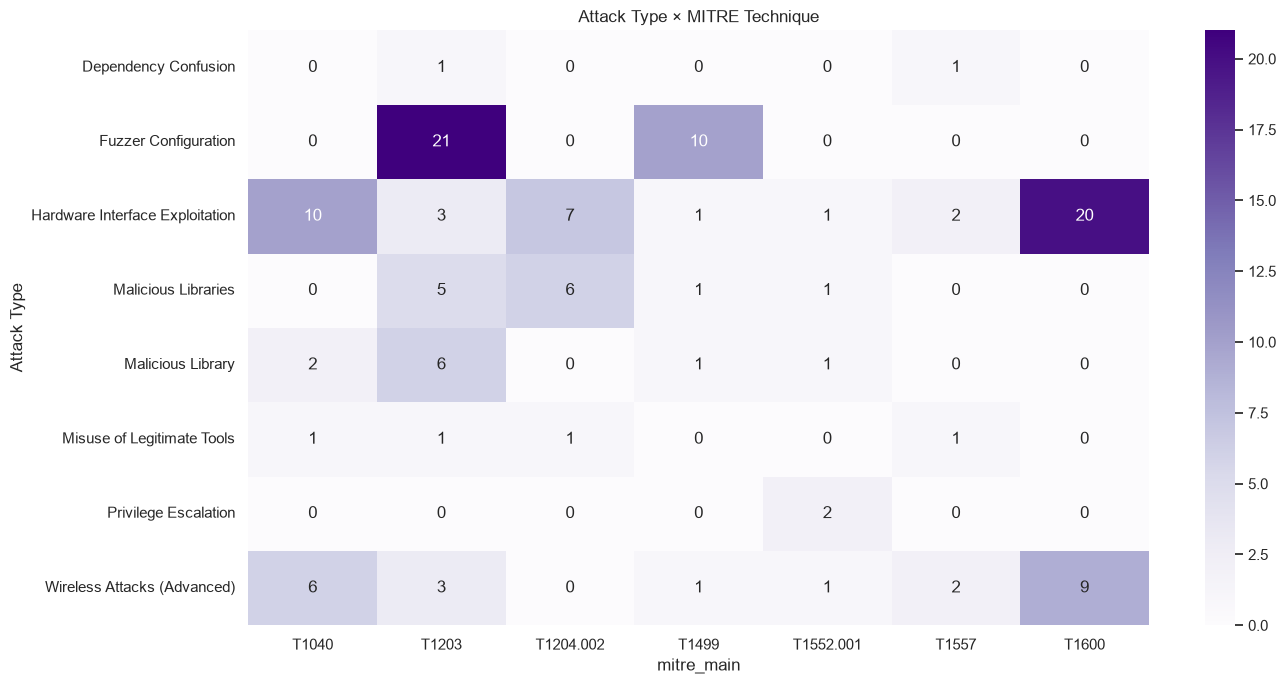

Вывод: наиболее выраженная связь в выбранной матрице — 'Fuzzer Configuration' с техникой T1203 (21 записей).
Тепловая карта показывает, что одни и те же MITRE-техники могут встречаться у разных `Attack Type`, но для отдельных типов атак формируются заметные локальные максимумы.


In [11]:
def first_mitre(value):
    if pd.isna(value):
        return np.nan
    found = re.findall(mitre_pattern, str(value))
    return found[0] if found else np.nan


df["mitre_main"] = df["MITRE Technique"].apply(first_mitre)

top8_attack = df["Attack Type"].value_counts().head(8).index
top10_mitre = df["mitre_main"].value_counts().head(10).index

subset = df[
    df["Attack Type"].isin(top8_attack)
    & df["mitre_main"].isin(top10_mitre)
]

ct_attack_mitre = pd.crosstab(subset["Attack Type"], subset["mitre_main"])
display(ct_attack_mitre)

plt.figure(figsize=(14, 7))
sns.heatmap(ct_attack_mitre, annot=True, fmt="d", cmap="Purples")
plt.title("Attack Type × MITRE Technique")
plt.tight_layout()
plt.show()

if not ct_attack_mitre.empty:
    strongest = ct_attack_mitre.stack().sort_values(ascending=False)
    pair = strongest.index[0]
    count = int(strongest.iloc[0])

    print(
        f"Вывод: наиболее выраженная связь в выбранной матрице — '{pair[0]}' с техникой {pair[1]} "
        f"({count} записей)."
    )
    print(
        "Тепловая карта показывает, что одни и те же MITRE-техники могут встречаться у разных `Attack Type`, "
        "но для отдельных типов атак формируются заметные локальные максимумы."
    )

## 10. Длины текстовых полей

,len_scenario_description,len_attack_steps,len_solution
count,14133.0,14133.0,14133.0
mean,127.6,698.1,63.0
std,90.9,464.7,38.0
min,30.0,23.0,0.0
25%,79.0,387.0,38.0
50%,103.0,554.0,50.0
75%,143.0,890.0,83.0
max,795.0,6003.0,520.0


,mean,median,max,iqr_outliers
field,,,,
Scenario Description,127.6,103.0,795,891
Attack Steps,698.1,554.0,6003,652
Solution,63.0,50.0,520,396


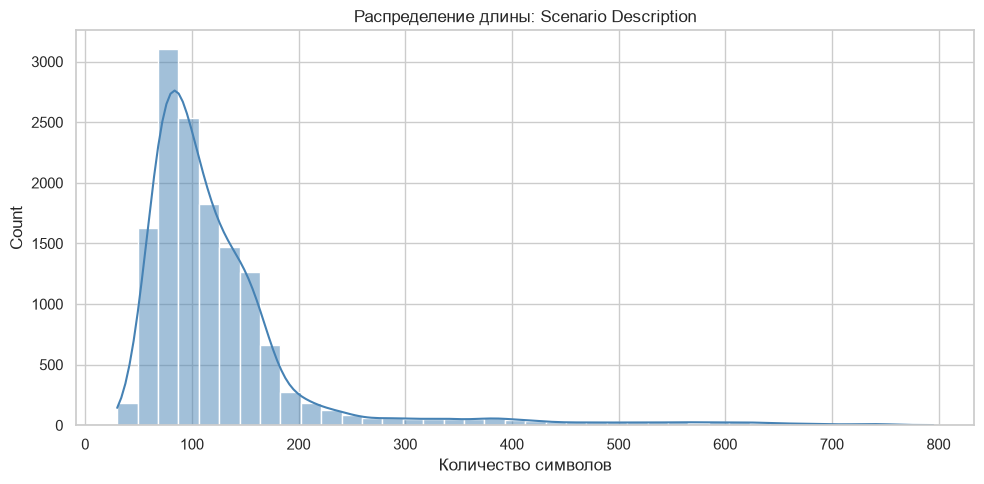

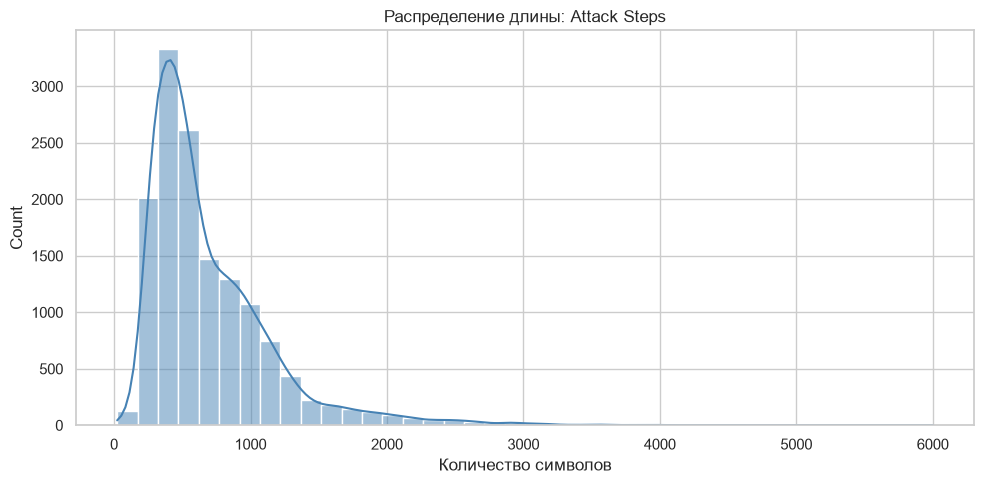

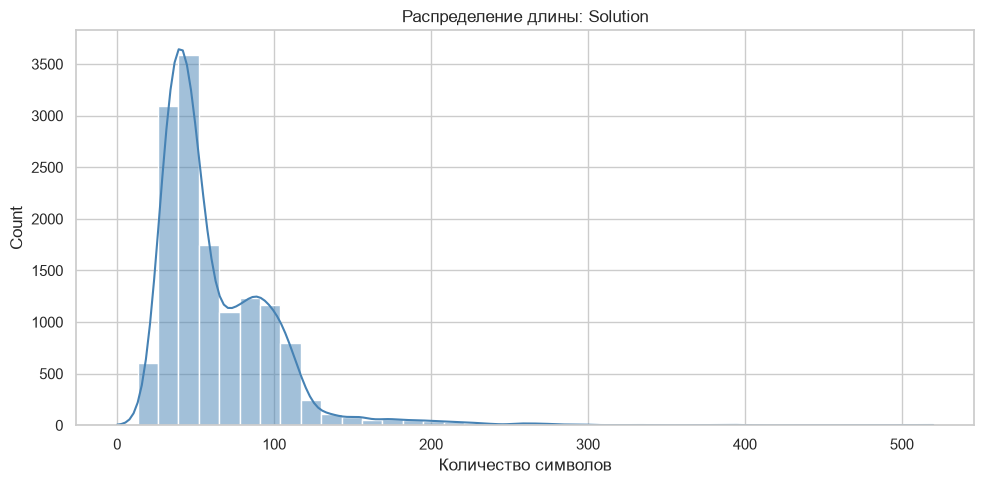

Вывод: самым длинным текстовым полем является `Attack Steps`: средняя длина 698.1, медиана 554.0, максимум 6 003 символов.
Выбросы по правилу 1.5×IQR присутствуют во всех трёх распределениях; это отражает наличие записей с существенно более подробными описаниями, шагами атаки или рекомендациями по защите.


In [12]:
text_columns = {
    "Scenario Description": "len_scenario_description",
    "Attack Steps": "len_attack_steps",
    "Solution": "len_solution",
}

for source_col, length_col in text_columns.items():
    df[length_col] = df[source_col].fillna("").astype(str).str.len()

length_cols = list(text_columns.values())
display(df[length_cols].describe().round(1))

outlier_rows = []
for source_col, length_col in text_columns.items():
    values = df[length_col]
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = int(((values < lower) | (values > upper)).sum())
    outlier_rows.append({
        "field": source_col,
        "mean": round(values.mean(), 1),
        "median": round(values.median(), 1),
        "max": int(values.max()),
        "iqr_outliers": outliers,
    })

outlier_table = pd.DataFrame(outlier_rows).set_index("field")
display(outlier_table)

for source_col, length_col in text_columns.items():
    plt.figure(figsize=(10, 5))
    sns.histplot(x=df[length_col], bins=40, kde=True, color="steelblue")
    plt.title(f"Распределение длины: {source_col}")
    plt.xlabel("Количество символов")
    plt.tight_layout()
    plt.show()

means = df[length_cols].mean().sort_values(ascending=False)
longest = means.index[0]
source_longest = {v: k for k, v in text_columns.items()}[longest]

print(
    f"Вывод: самым длинным текстовым полем является `Attack Steps`: средняя длина {df['len_attack_steps'].mean():.1f}, "
    f"медиана {df['len_attack_steps'].median():.1f}, максимум {fmt_int(df['len_attack_steps'].max())} символов."
)
print(
    "Выбросы по правилу 1.5×IQR присутствуют во всех трёх распределениях; это отражает наличие записей "
    "с существенно более подробными описаниями, шагами атаки или рекомендациями по защите."
)

## 11. Частые слова в `Solution`

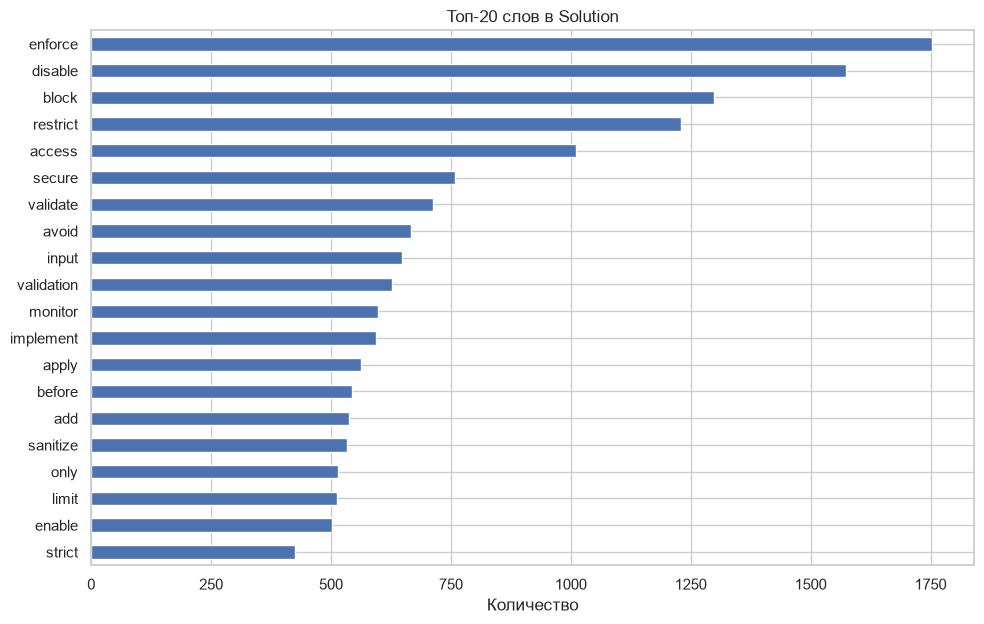

,count
enforce,1753
disable,1573
block,1298
restrict,1229
access,1011
secure,758
validate,712
avoid,666
input,647
validation,628


Вывод: наиболее частая лексика рекомендаций — enforce (1753), disable (1573), block (1298), restrict (1229), access (1011), secure (758), validate (712), avoid (666), input (647), validation (628).
По смыслу наиболее частые рекомендации сосредоточены вокруг ограничения доступа, блокирования/отключения опасных возможностей, усиления защиты, проверки и валидации входных данных, а также мониторинга.


In [13]:
STOP_WORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "for", "on", "with", "by", "from",
    "is", "are", "be", "as", "at", "that", "this", "these", "those", "it", "its", "into",
    "can", "should", "would", "could", "such", "using", "use", "used", "ensure", "all",
    "your", "their", "they", "you", "we", "not", "if", "when", "where", "which", "who",
    "application", "applications", "system", "systems", "data"
}

solution_words = []
for text in df["Solution"].dropna().astype(str):
    tokens = re.findall(r"[A-Za-z][A-Za-z\-]+", text.lower())
    solution_words.extend(
        token for token in tokens
        if token not in STOP_WORDS and len(token) > 2
    )

solution_counter = Counter(solution_words)
top_solution = plot_counter(solution_counter, 20, "Топ-20 слов в Solution")
display(top_solution.sort_values(ascending=False).to_frame("count"))

top10_solution = solution_counter.most_common(10)
print(
    "Вывод: наиболее частая лексика рекомендаций — "
    + ", ".join(f"{name} ({count})" for name, count in top10_solution)
    + "."
)
print(
    "По смыслу наиболее частые рекомендации сосредоточены вокруг ограничения доступа, блокирования/отключения опасных возможностей, "
    "усиления защиты, проверки и валидации входных данных, а также мониторинга."
)

## 12. Финальная сводка по исходным полям

In [14]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=True),
})
display(summary)

original_df = df.iloc[:, :15]
print(f"Вывод: итоговый набор содержит {len(df):,} строк. Category включает {df['Category'].nunique()} уникальных значений, Attack Type — {df['Attack Type'].nunique()}, а mitre_main — {df['mitre_main'].nunique()} уникальных кодов.")
print(f"Качество заполнения высокое: суммарная доля пропусков в исходных 15 полях составляет {original_df.isna().sum().sum() / original_df.size * 100:.2f}%, полных дубликатов — {original_df.duplicated().sum()}.")

,dtype,non_null,missing,missing_%,unique
id,int64,14133,0,0.00,14133
Title,str,14133,0,0.00,13793
Category,str,14133,0,0.00,64
Attack Type,str,14133,0,0.00,8834
Scenario Description,str,14133,0,0.00,13866
Attack Steps,str,14133,0,0.00,13895
Tools Used,str,14119,14,0.10,12935
Target Type,str,14129,4,0.03,9885
Vulnerability,str,14115,18,0.13,13424
MITRE Technique,str,14109,24,0.17,5770


Вывод: итоговый набор содержит 14,133 строк. Category включает 64 уникальных значений, Attack Type — 8834, а mitre_main — 754 уникальных кодов.
Качество заполнения высокое: суммарная доля пропусков в исходных 15 полях составляет 0.11%, полных дубликатов — 0.


## Финальные выводы

In [15]:
main_categories = df["Category"].value_counts().head(3)
main_attacks = df["Attack Type"].value_counts().head(3)
main_tools = tools_counter.most_common(5)
main_mitre = mitre_counter.most_common(5)
main_tags = tags_counter.most_common(5)
main_sources = sources_counter.most_common(7)
main_solution = solution_counter.most_common(8)
original_df = df.iloc[:, :15]
missing_pct = 100 * original_df.isna().sum().sum() / original_df.size
duplicate_count = int(original_df.duplicated().sum())
attack_unique_ratio = df["Attack Type"].nunique(dropna=True) / df["Attack Type"].notna().sum() * 100

print("ФИНАЛЬНЫЕ ВЫВОДЫ")
print("=" * 70)
print(f"1. Категории и типы атак. Представлено {df['Category'].nunique()} категории. Наиболее частые: " + ", ".join(f"{name} ({count})" for name, count in main_categories.items()) + f". Максимальная доля одной категории — {main_categories.iloc[0] / len(df) * 100:.2f}%, поэтому выраженного доминирования нет. Attack Type имеет {df['Attack Type'].nunique()} уникальных значений ({attack_unique_ratio:.2f}% от числа строк); наиболее частые: " + ", ".join(f"{name} ({count})" for name, count in main_attacks.items()) + ".")
print("2. Инструменты. Наиболее часто встречаются " + ", ".join(f"{name} ({count})" for name, count in main_tools) + ". Их состав отражает сочетание веб-тестирования, анализа сетевого трафика, автоматизации и ручной проверки HTTP/API.")
print("3. MITRE ATT&CK. После извлечения кодов найдено " + str(len(mitre_counter)) + " уникальных техник. Чаще всего встречаются " + ", ".join(f"{name} ({count})" for name, count in main_mitre) + ". Наблюдается ядро наиболее частых техник при широком общем покрытии.")
print("4. Теги и источники. Наиболее частые теги: " + ", ".join(f"{name} ({count})" for name, count in main_tags) + ". Среди источников лидируют " + ", ".join(f"{name} ({count})" for name, count in main_sources) + ". Представлены как моделируемые/учебные сценарии, так и профильные источники OWASP, MITRE ATT&CK, HackTricks и SANS.")
print("5. Рекомендации по защите. Наиболее частая лексика Solution: " + ", ".join(f"{name} ({count})" for name, count in main_solution) + ". Она указывает на повторяющиеся меры: контроль доступа, ограничение/отключение опасных возможностей, блокирование, безопасную конфигурацию, проверку и очистку входных данных.")
print(f"6. Качество данных. Суммарная доля пропусков в исходных полях составляет {missing_pct:.2f}%, полных дубликатов — {duplicate_count}. Небольшое число пропусков не оказывает существенного влияния на общую картину EDA.")
print(f"7. Общий вывод. Предоставленный для РК датасет содержит {len(df):,} записей, имеет высокое качество заполнения и большое разнообразие категорий, типов атак, инструментов, тегов, источников и MITRE-техник. По совокупности характеристик он предоставляет достаточную информационную базу для поставленного в работе EDA-анализа SQL-инъекций и связанных характеристик атак.")

ФИНАЛЬНЫЕ ВЫВОДЫ
1. Категории и типы атак. Представлено 64 категории. Наиболее частые: Insider Threat (569), Physical / Hardware Attacks (548), Quantum Cryptography & Post-Quantum Threats (542). Максимальная доля одной категории — 4.03%, поэтому выраженного доминирования нет. Attack Type имеет 8834 уникальных значений (62.51% от числа строк); наиболее частые: Hardware Interface Exploitation (161), Wireless Attacks (Advanced) (95), Dependency Confusion (91).
2. Инструменты. Наиболее часто встречаются Burp Suite (1117), Wireshark (711), Python (507), curl (486), Postman (289). Их состав отражает сочетание веб-тестирования, анализа сетевого трафика, автоматизации и ручной проверки HTTP/API.
3. MITRE ATT&CK. После извлечения кодов найдено 772 уникальных техник. Чаще всего встречаются T1203 (740), T1499 (401), T1606 (352), T1552.001 (302), T1040 (280). Наблюдается ядро наиболее частых техник при широком общем покрытии.
4. Теги и источники. Наиболее частые теги: redteam (271), phishing (202)